# Organize Data & Compute Insights — Product & Category Level
This notebook prepares statistics for the summarization. 

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
#from nltk.corpus import stopwords

#pd.set_option("display.max_colwidth", 120)

## 2. Load data


In [2]:
DATA_PATH = "../data/processed/reviews_with_clusters.csv"

df = pd.read_csv(DATA_PATH)
df.rename(columns={'label': 'sentiment'}, inplace=True)
print(df.shape)
df.head()

(30741, 12)


,asins,categories,id,name,primaryCategories,reviews.rating,reviews.text,reviews.title,clean_text,sentiment,cluster,cluster_name
0,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,3,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,i order 3 of them and one of the item is bad q...,neutral,0,Household & Pet Supplies
1,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,4,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,bulk is always the less expensive way to go fo...,positive,0,Household & Pet Supplies
2,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,well they are not duracell but for the price i...,positive,0,Household & Pet Supplies
3,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,seem to work as well as name brand batteries a...,positive,0,Household & Pet Supplies
4,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,these batteries are very long lasting the pric...,positive,0,Household & Pet Supplies


In [3]:
# Update these to match your actual column names
CATEGORY_COL = "cluster_name"     # the 5 manually-named clusters from task 2
PRODUCT_COL = "name"          # product name
META_CATEGORY_COL = "categories" # the 79 metadata categories
RATING_COL = "reviews.rating"       # product reviews
REVIEW_COL = "clean_text"             # cleaned review text from task 1

df[[CATEGORY_COL, PRODUCT_COL, RATING_COL, REVIEW_COL]].head()

,cluster_name,name,reviews.rating,clean_text
0,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,3,i order 3 of them and one of the item is bad q...
1,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,4,bulk is always the less expensive way to go fo...
2,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,5,well they are not duracell but for the price i...
3,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,5,seem to work as well as name brand batteries a...
4,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,5,these batteries are very long lasting the pric...


## 3. Distribution of products and reviews across categories


In [4]:
print("Categories:", df[CATEGORY_COL].unique())
print("\nReviews per category:")
print(df[CATEGORY_COL].value_counts())
print("\nUnique products per category:")
print(df.groupby(CATEGORY_COL)[PRODUCT_COL].nunique())

Categories: <ArrowStringArray>
[     'Household & Pet Supplies', 'TV, Streaming & Media Players',
            'Smart Home Devices', 'Electronic Device Accessories',
              'Kindle E-Readers',            'Electronic Devices']
Length: 6, dtype: str

Reviews per category:
cluster_name
Electronic Devices               16157
Household & Pet Supplies         11018
Smart Home Devices                2200
Kindle E-Readers                  1207
Electronic Device Accessories      137
TV, Streaming & Media Players       22
Name: count, dtype: int64

Unique products per category:
cluster_name
Electronic Device Accessories    12
Electronic Devices               27
Household & Pet Supplies          8
Kindle E-Readers                 13
Smart Home Devices               14
TV, Streaming & Media Players     5
Name: name, dtype: int64


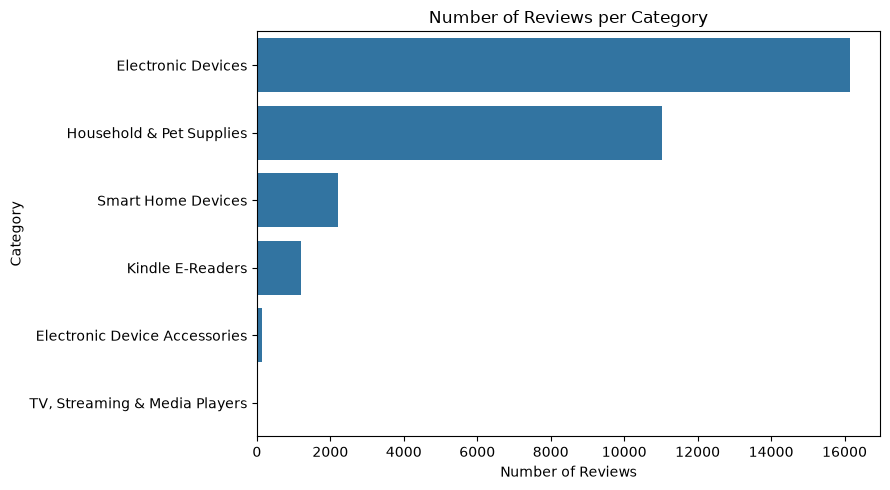

In [5]:
# Count reviews per category
reviews_per_category = df[CATEGORY_COL].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=reviews_per_category.values, y=reviews_per_category.index)
plt.title("Number of Reviews per Category")
plt.xlabel("Number of Reviews")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

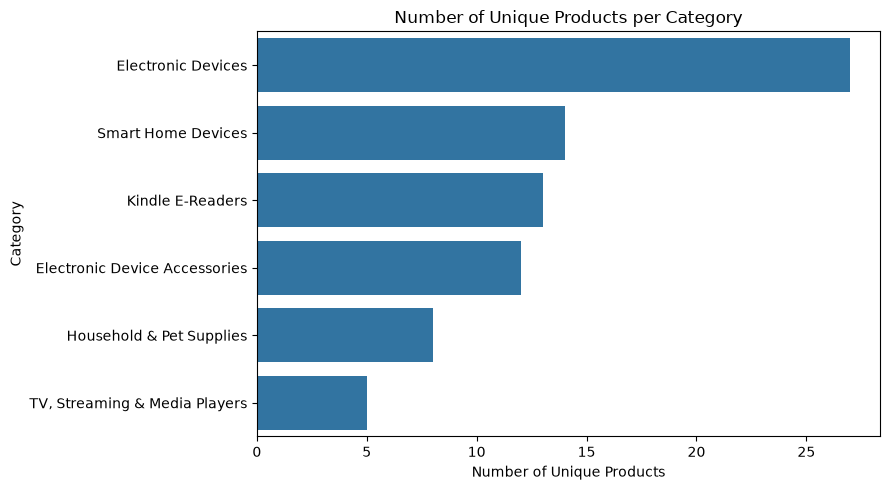

In [6]:
# Count unique products per category
products_per_category = df.groupby(CATEGORY_COL)[PRODUCT_COL].nunique().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=products_per_category.values,y=products_per_category.index)
plt.title("Number of Unique Products per Category")
plt.xlabel("Number of Unique Products")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 4. Product-level statistics
For every product: average rating, number of reviews, and sentiment breakdown. Review text is not stored raw; instead, the next section extracts compact positive and negative topic words using TF-IDF.


In [7]:
def count_sentiment(group, sentiment):
    return int((group["sentiment"] == sentiment).sum())

product_rows = []
for (category, product), group in df.groupby([CATEGORY_COL, PRODUCT_COL]):
    product_rows.append({
        "category": category,
        "product_name": product,
        "avg_rating": round(group[RATING_COL].mean(), 2),
        "num_reviews": len(group),
        "pct_positive": round((group["sentiment"] == "positive").mean() * 100, 1),
        "pct_neutral": round((group["sentiment"] == "neutral").mean() * 100, 1),
        "pct_negative": round((group["sentiment"] == "negative").mean() * 100, 1),
        "overall_sentiment" : group["sentiment"].value_counts().idxmax(),
        #"num_positive_reviews": count_sentiment(group, "positive"),
        #"num_negative_reviews": count_sentiment(group, "negative"),
    })

product_stats = pd.DataFrame(product_rows)
print(product_stats.shape)
product_stats.sort_values("num_reviews", ascending=False).head()


(79, 8)


,category,product_name,avg_rating,num_reviews,pct_positive,pct_neutral,pct_negative,overall_sentiment
40,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,4.40,7553,84.6,4.8,10.6,positive
39,Household & Pet Supplies,AmazonBasics AA Performance Alkaline Batteries...,4.41,3442,85.0,5.0,10.0,positive
29,Electronic Devices,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4.60,2441,95.2,3.0,1.8,positive
17,Electronic Devices,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.58,2369,94.6,3.4,2.0,positive
34,Electronic Devices,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",4.53,1663,91.3,5.5,3.2,positive


## 5. Top positive & negative keywords per product
A simple, transparent way to surface "top complaints" without any model: count the most frequent meaningful words in NEGATIVE reviews only. This is just word frequency — good enough to point the generative model at the right themes later.

In [8]:
TOP_N_WORDS = 50

def top_tfidf_words(texts, top_n=TOP_N_WORDS):
    """Return the highest-scoring TF-IDF terms for a set of reviews."""
    texts = [str(t).strip() for t in texts if pd.notna(t) and str(t).strip()]
    if not texts:
        return []

    # Fit TF-IDF within this product/sentiment group so words specific to
    # that product's positive or negative feedback are emphasized.
    vectorizer = TfidfVectorizer(
        stop_words="english",
        #lowercase=True,
        #token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']{2,}\b",
        max_features=5000,
        ngram_range=(1, 2)
    )

    try:
        matrix = vectorizer.fit_transform(texts)
        #print(matrix.shape)
    except ValueError:
        return []

    scores = np.asarray(matrix.mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top_indices = scores.argsort()[::-1][:top_n]

    return [terms[i] for i in top_indices]


# Extract compact topic words instead of storing raw review examples.
product_keyword_rows = []

for (category, product), group in df.groupby([CATEGORY_COL, PRODUCT_COL]):
    positive_reviews = group.loc[
        group["sentiment"] == "positive", REVIEW_COL
    ].dropna().tolist()

    negative_reviews = group.loc[
        group["sentiment"] == "negative", REVIEW_COL
    ].dropna().tolist()

    product_keyword_rows.append({
        "category": category,
        "product_name": product,
        "top_positive_words": top_tfidf_words(positive_reviews),
        "top_negative_words": top_tfidf_words(negative_reviews),
    })

product_keywords = pd.DataFrame(product_keyword_rows)

product_stats = product_stats.merge(
    product_keywords,
    on=["category", "product_name"],
    how="left"
)

#product_stats[["product_name", "top_positive_words", "top_negative_words"]].head()

In [9]:
product_stats.sample(10)

,category,product_name,avg_rating,num_reviews,pct_positive,pct_neutral,pct_negative,overall_sentiment,top_positive_words,top_negative_words
46,Household & Pet Supplies,Two Door Top Load Pet Kennel Travel Crate Dog ...,5.00,1,100.0,0.0,0.0,positive,"[easy, tops lifts, sturdy lightweight, tops, p...",[]
61,Smart Home Devices,Amazon - Echo Plus w/ Built-In Hub - Silver,4.75,590,96.3,2.4,1.4,positive,"[great, love, echo, alexa, easy, use, plus, sm...","[answers, great, returned, google, like, hub, ..."
29,Electronic Devices,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4.60,2441,95.2,3.0,1.8,positive,"[tablet, great, use, price, love, easy, good, ...","[tablet, amazon, just, bought, good, use, ipad..."
70,Smart Home Devices,AmazonBasics Silicone Hot Handle Cover/Holder ...,4.00,1,100.0,0.0,0.0,positive,"[slippes pan, slippes, pan handle, pan, handle]",[]
40,Household & Pet Supplies,AmazonBasics AAA Performance Alkaline Batterie...,4.40,7553,84.6,4.8,10.6,positive,"[batteries, great, good, price, work, long, gr...","[batteries, long, don, work, buy, battery, ama..."
64,Smart Home Devices,Amazon Echo Show - Black,5.00,1,100.0,0.0,0.0,positive,"[wish stop, wish, whats going, whats, went sal...",[]
33,Electronic Devices,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",4.53,1268,91.6,5.3,3.2,positive,"[tablet, great, loves, kids, love, old, year, ...","[tablet, kids, good, charge, apps, slow, games..."
71,Smart Home Devices,Certified Refurbished Amazon Echo,5.00,7,100.0,0.0,0.0,positive,"[echo, great, just, expected works, works, jus...",[]
20,Electronic Devices,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.56,163,93.9,3.1,3.1,positive,"[tablet, great, easy, kindle, love, use, amazo...","[apps, junk, week, needed, department, ebooks,..."
56,Kindle E-Readers,Kindle Oasis E-reader with Leather Charging Co...,4.67,60,96.7,1.7,1.7,positive,"[kindle, oasis, light, cover, battery, great, ...","[year old, year, week lights, week, weak piece..."


## 6. Category-level aggregation
For each of the 5 categories:
- Top 3 products (ranked by a simple score combining rating + review volume, so a 5-star product with 2 reviews doesn't beat a 4.5-star product with 500 reviews)
- Worst product (lowest average rating, with a minimum review count so it's not just noise)
- Overall category stats

In [10]:
def rank_score(row):
    # Simple, explainable ranking: rating weighted by log of review volume
    return row["avg_rating"] * np.log1p(row["num_reviews"])

category_insights = {}

for category in product_stats["category"].unique():
    cat_products = product_stats[product_stats["category"] == category].copy()
    cat_products["rank_score"] = cat_products.apply(rank_score, axis=1)
    top_3 = cat_products.sort_values("rank_score", ascending=False).head(3)
    last_3 = cat_products.sort_values("rank_score", ascending=False).tail(3)
    worst = cat_products.sort_values("avg_rating", ascending=True).iloc[0]

    category_insights[category] = {
        "category_stats": {
            "num_products": int(cat_products.shape[0]),
            "num_reviews": int(cat_products["num_reviews"].sum()),
            "avg_rating": round(float(cat_products["avg_rating"].mean()), 2),
        },
        "top_3_products": top_3.drop(columns="rank_score").to_dict(orient="records"),
        "last_3_products": last_3.drop(columns="rank_score").to_dict(orient="records"),
        "worst_product": worst.drop(labels="rank_score").to_dict(),
        #"all_products": cat_products.to_dict(orient="records"),
    }

list(category_insights.keys())

['Electronic Device Accessories',
 'Electronic Devices',
 'Household & Pet Supplies',
 'Kindle E-Readers',
 'Smart Home Devices',
 'TV, Streaming & Media Players']

## 7. Quick look at one category
Sanity-check the structure before saving.

In [11]:
sample_category = list(category_insights.keys())[0]
print("Category:", sample_category)
print("Stats:", category_insights[sample_category]["category_stats"])
print("\nTop 3 products:")
for p in category_insights[sample_category]["top_3_products"]:
    print(" -", p["product_name"], "| avg_rating:", p["avg_rating"], "| reviews:", p["num_reviews"])
print("\nLast 3 products:")
for p in category_insights[sample_category]["last_3_products"]:
    print(" -", p["product_name"], "| avg_rating:", p["avg_rating"], "| reviews:", p["num_reviews"])
print("\nWorst product:", category_insights[sample_category]["worst_product"]["product_name"],
      "| avg_rating:", category_insights[sample_category]["worst_product"]["avg_rating"])

Category: Electronic Device Accessories
Stats: {'num_products': 12, 'num_reviews': 137, 'avg_rating': 4.12}

Top 3 products:
 - Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders | avg_rating: 4.7 | reviews: 43
 - AmazonBasics 15.6-Inch Laptop and Tablet Bag | avg_rating: 4.52 | reviews: 21
 - AmazonBasics Backpack for Laptops up to 17-inches | avg_rating: 4.16 | reviews: 25

Last 3 products:
 - Amazon Kindle Replacement Power Adapter (Fits Latest Generation Kindle and Kindle DX) For shipment in the U.S only | avg_rating: 2.8 | reviews: 5
 - AmazonBasics 11.6-Inch Laptop Sleeve | avg_rating: 4.0 | reviews: 2
 - Oem Amazon Kindle Power Usb Adapter Wall Travel Charger Fire/dx/+micro Usb Cable | avg_rating: 1.0 | reviews: 4

Worst product: Oem Amazon Kindle Power Usb Adapter Wall Travel Charger Fire/dx/+micro Usb Cable | avg_rating: 1.0


In [12]:
sample_category = list(category_insights.keys())[5]
print("Category:", sample_category)
print("Stats:", category_insights[sample_category]["category_stats"])
print("\nTop 3 products:")
for p in category_insights[sample_category]["top_3_products"]:
    print(" -", p["product_name"], "| avg_rating:", p["avg_rating"], "| reviews:", p["num_reviews"])
print("\nLast 3 products:")
for p in category_insights[sample_category]["last_3_products"]:
    print(" -", p["product_name"], "| avg_rating:", p["avg_rating"], "| reviews:", p["num_reviews"])
print("\nWorst product:", category_insights[sample_category]["worst_product"]["product_name"],
      "| avg_rating:", category_insights[sample_category]["worst_product"]["avg_rating"])

Category: TV, Streaming & Media Players
Stats: {'num_products': 5, 'num_reviews': 22, 'avg_rating': 4.34}

Top 3 products:
 - Fire TV Stick Streaming Media Player Pair Kit | avg_rating: 5.0 | reviews: 6
 - Amazon Fire TV with 4K Ultra HD and Alexa Voice Remote (Pendant Design) | Streaming Media Player | avg_rating: 5.0 | reviews: 4
 - AmazonBasics Nylon CD/DVD Binder (400 Capacity) | avg_rating: 4.25 | reviews: 4

Last 3 products:
 - AmazonBasics Nylon CD/DVD Binder (400 Capacity) | avg_rating: 4.25 | reviews: 4
 - Amazon Fire TV Gaming Edition Streaming Media Player | avg_rating: 4.67 | reviews: 3
 - Certified Refurbished Amazon Fire TV with Alexa Voice Remote | avg_rating: 2.8 | reviews: 5

Worst product: Certified Refurbished Amazon Fire TV with Alexa Voice Remote | avg_rating: 2.8


## 8. Save the organized insights
This JSON contains compact product/category statistics and TF-IDF topic words for the summarization notebooks.

In [13]:
len(category_insights)

6

In [15]:
OUTPUT_PATH = "../data/processed/category_insights.json"

with open(OUTPUT_PATH, "w") as f:
    json.dump(category_insights, f, indent=2)

print("Saved:", OUTPUT_PATH)

Saved: ../data/processed/category_insights.json


# Notes

- Prepared **review statistics and information along with the corresponding cluster names** to provide structured input to the summarization model.
- Used **TF-IDF** to identify the most important and frequently occurring words in **positive and negative reviews**, instead of passing the complete raw reviews to the model. This helps reduce the input size while retaining key information from the reviews.
- Generated **cluster-wise and product-wise statistics** and saved them in **JSON format** to enable efficient retrieval and tool calling by the GenAI model.